# 04 Model Evaluation

**Goal:** Full out-of-sample evaluation of the three competing models.

Covers: per-window results table, performance-over-time charts, pooled OOS ROC/PR, confusion matrices, lift curves (with naive-rule comparison), probability calibration, and class-imbalance / threshold optimisation with a business cost surface.

In [197]:
import warnings; warnings.filterwarnings('ignore')
import importlib
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config
set_config(transform_output='pandas')
from sklearn.metrics import roc_auc_score, average_precision_score

from src.config import COST_FP, COST_FN
from src.evaluation import compute_threshold_metrics, calibrate_isotonic
import src.reporting; importlib.reload(src.reporting)
from src.reporting import (
    plot_performance_over_time, plot_roc_pr_score_dist, plot_confusion_matrices,
    plot_lift_curves, plot_calibration, plot_score_distributions,
    plot_threshold_analysis,
)


## 1. Load Artifacts

In [198]:
with open('artifacts/window_results.pkl', 'rb') as f:
    _saved = pickle.load(f)
window_results = _saved['window_results']
obs_months     = _saved['obs_months']

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('y_test','boost_prob','xgb_prob','lr_prob')}
    for r in window_results
])

all_y     = np.concatenate([r['y_test']     for r in window_results])
boost_all = np.concatenate([r['boost_prob'] for r in window_results])
xgb_all   = np.concatenate([r['xgb_prob']  for r in window_results])
lr_all    = np.concatenate([r['lr_prob']    for r in window_results])

print(f'{len(window_results)} windows loaded  |  {len(all_y):,} pooled OOS rows')
print(f'Pooled churn rate: {all_y.mean():.3%}')

7 windows loaded  |  690,619 pooled OOS rows
Pooled churn rate: 12.349%


## 2. Per-Window Results

| Metric | Boost | XGBoost | LR |
|--------|-------|---------|----|
| ROC-AUC (mean) | 0.8920 | 0.8913 | 0.8634 |
| PR-AUC  (mean) | 0.6419 | 0.6406 | 0.5898 |

HistGBM and XGBoost are within fold noise (~0.001–0.003 AUC) confirming they
are interchangeable. LR is 3 points behind — acceptable as an interpretable baseline.
The gap narrows in low-signal windows, confirming boosting's advantage is consistent.

In [199]:
pd.set_option('display.float_format', '{:.4f}'.format)
print(f'{"Metric":<25} {"Boost mean":>12} {"Boost std":>10} '
      f'{"XGB mean":>10} {"XGB std":>8} {"LR mean":>10} {"LR std":>8}')
print('-' * 88)
for metric, label in [('boost_auc', 'ROC-AUC'), ('boost_pr', 'PR-AUC')]:
    xl = metric.replace('boost', 'xgb')
    ll = metric.replace('boost', 'lr')
    print(f'{label:<25} {results_df[metric].mean():>12.4f} {results_df[metric].std():>10.4f} '
          f'{results_df[xl].mean():>10.4f} {results_df[xl].std():>8.4f} '
          f'{results_df[ll].mean():>10.4f} {results_df[ll].std():>8.4f}')
print()
print(results_df[['test_month','boost_auc','boost_pr','xgb_auc','xgb_pr',
                   'lr_auc','lr_pr','churn_rate','n_test']].to_string(index=False))

Metric                      Boost mean  Boost std   XGB mean  XGB std    LR mean   LR std
----------------------------------------------------------------------------------------
ROC-AUC                         0.8920     0.0029     0.8913   0.0028     0.8634   0.0067
PR-AUC                          0.6419     0.0106     0.6406   0.0104     0.5898   0.0150

test_month  boost_auc  boost_pr  xgb_auc  xgb_pr  lr_auc  lr_pr  churn_rate  n_test
2023-11-01     0.8924    0.6364   0.8921  0.6346  0.8586 0.5754      0.1222  111761
2023-12-01     0.8892    0.6235   0.8887  0.6220  0.8649 0.5724      0.1203  106627
2024-01-01     0.8902    0.6460   0.8896  0.6442  0.8672 0.5992      0.1266  103172
2024-02-01     0.8889    0.6427   0.8880  0.6414  0.8557 0.5910      0.1250   98259
2024-03-01     0.8912    0.6380   0.8908  0.6387  0.8572 0.5794      0.1222   94012
2024-04-01     0.8957    0.6518   0.8946  0.6509  0.8652 0.5974      0.1269   90423
2024-05-01     0.8960    0.6550   0.8950  0.6525  0.

## 3. Performance Over Time

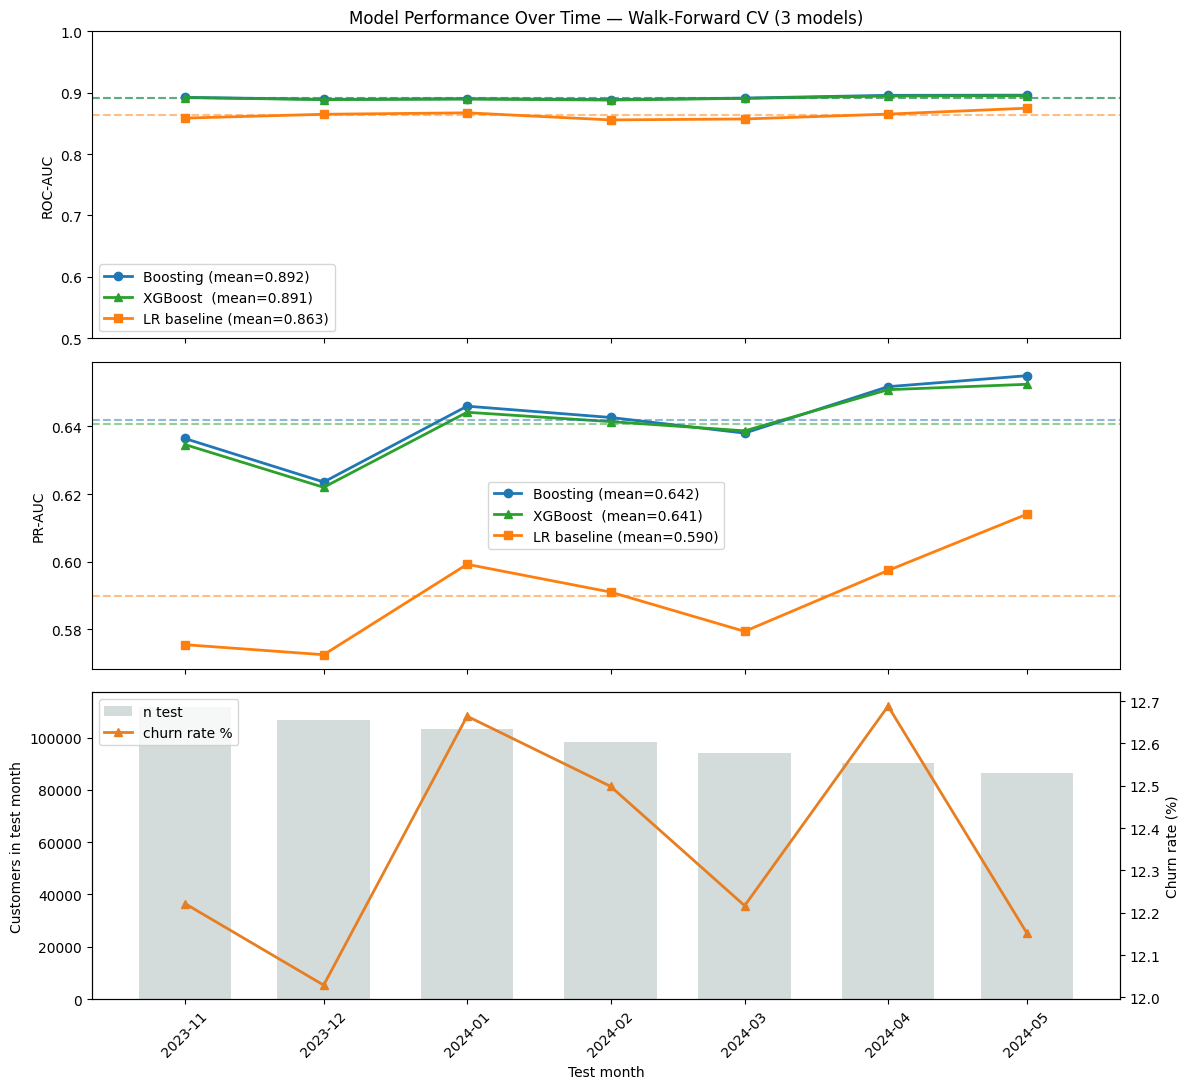

In [200]:
plot_performance_over_time(results_df)

 The three models are running flat and parallel across seven windows, with no single month collapsing. This shows stable performance across a changing churn rate i.e. it means the model isn't fitting a phase that has already passed.

## 4. Pooled OOS Evaluation

Concatenating all seven test-month predictions gives ~690k genuinely out-of-sample rows.

**Lead metric — capacity-constrained lift:** calling the top 10% of the ranked list reaches ~53% of all churners (5.3× lift). That translates directly into retention team capacity: with budget to contact N customers, the model tells you which N to prioritise.

ROC-AUC (0.891) and PR-AUC (0.640) are the headline accuracy metrics. PR-AUC is more informative than ROC under ~12% class imbalance because it ignores true negatives and focuses entirely on the minority class.

Pooled ROC-AUC   Boosting: 0.8914  XGBoost: 0.8909  LR: 0.8628
Pooled PR-AUC    Boosting: 0.6403  XGBoost: 0.6397  LR: 0.5882


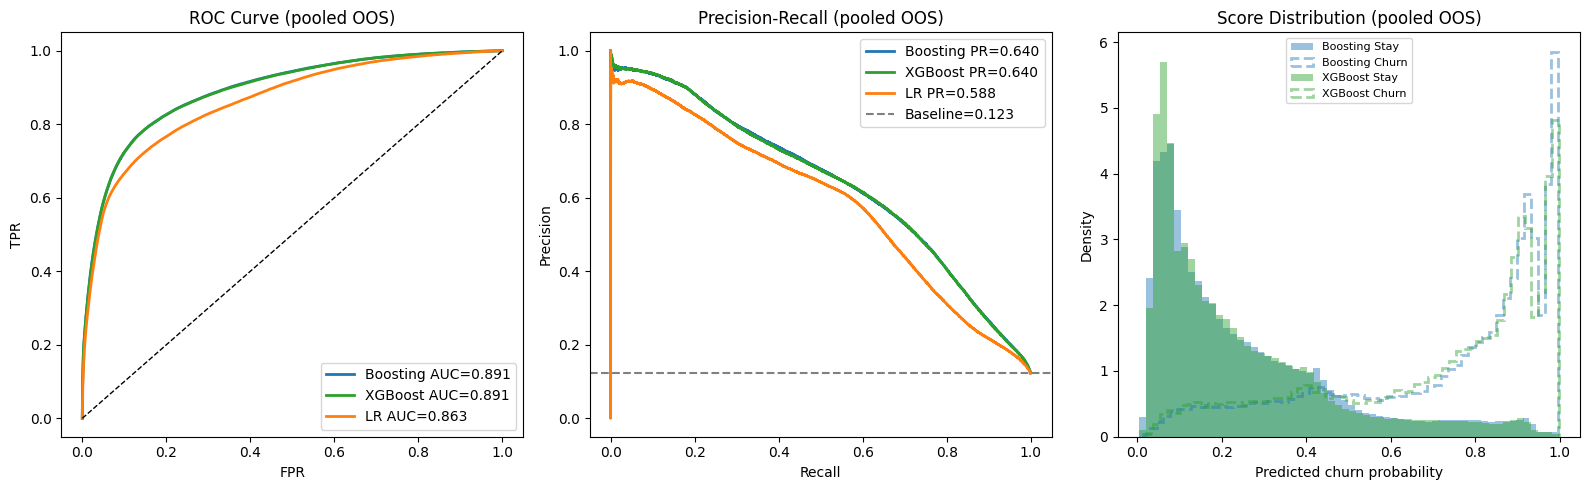

In [201]:
print(f'Pooled ROC-AUC   Boosting: {roc_auc_score(all_y, boost_all):.4f}  '
      f'XGBoost: {roc_auc_score(all_y, xgb_all):.4f}  LR: {roc_auc_score(all_y, lr_all):.4f}')
print(f'Pooled PR-AUC    Boosting: {average_precision_score(all_y, boost_all):.4f}  '
      f'XGBoost: {average_precision_score(all_y, xgb_all):.4f}  LR: {average_precision_score(all_y, lr_all):.4f}')

plot_roc_pr_score_dist(all_y, boost_all, xgb_all, lr_all)

## 5. Confusion Matrices


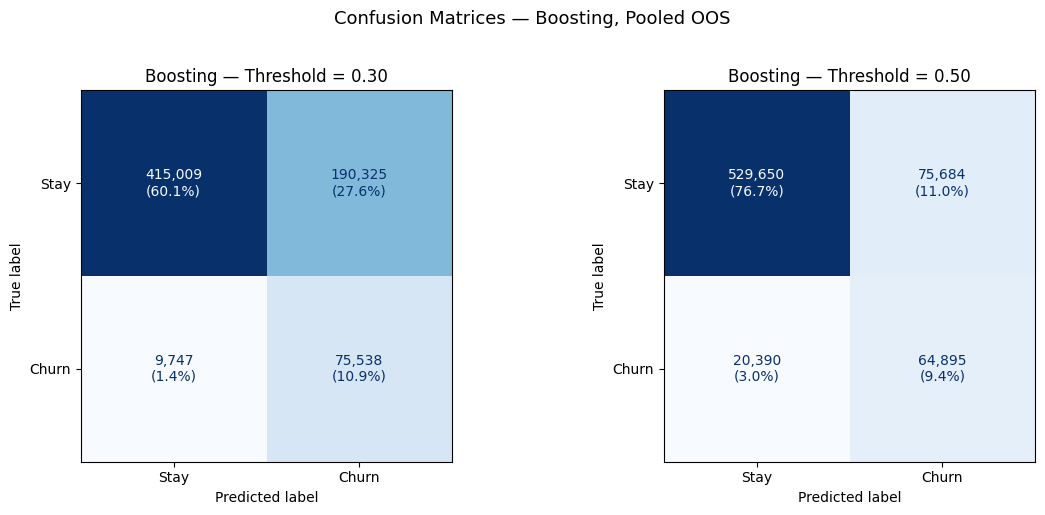

In [202]:
plot_confusion_matrices(all_y, boost_all, thresholds=(0.30, 0.50))

## 6. Cumulative Gain & Lift Curves

The lift curve shows the model's ability to concentrate churners at the top of the ranked list, it directly answers the question the retention team actually asks: *"if we can only contact X% of customers, how many leavers do we reach?"*

**Model vs naive rule.** Before trusting the model, I wanted to check whether a simple rule could do the same job, just flag everyone whose contract is about to end (`contract_status_risk = 'approaching_ooc'`). The cell below works out how many churners that rule actually catches and drops it onto the lift curve as the diamond marker, so you can see directly what the model adds on top of it.

In [203]:
# ── Load OOS feature data for the rule comparison ──────────────────────────
_rule_master = pd.read_parquet('artifacts/master.parquet', engine='pyarrow')
_rule_master['datevalue'] = pd.to_datetime(_rule_master['datevalue'])
_test_months = [r['test_month'] for r in window_results]
_oos = _rule_master[_rule_master['datevalue'].isin(_test_months)].copy()

# Naive rule: flag customers approaching end of contract
_rule_flag    = _oos['contract_status_risk'].eq('approaching_ooc')
_rule_pct_pop = _rule_flag.mean()
_rule_pct_churn = _oos.loc[_rule_flag, 'label'].sum() / _oos['label'].sum()
_rule_lift    = _rule_pct_churn / _rule_pct_pop

# Model at the same % coverage as the rule
_n_rule = int(_rule_pct_pop * len(all_y))
_model_pct_churn = all_y[np.argsort(boost_all)[::-1][:_n_rule]].sum() / all_y.sum()
_model_lift = _model_pct_churn / _rule_pct_pop

print(f"Naive approaching-OOC rule:")
print(f"  Flags    : {_rule_pct_pop:.1%} of customers")
print(f"  Captures : {_rule_pct_churn:.1%} of churners  (lift = {_rule_lift:.1f}×)")
print()
print(f"Model at same {_rule_pct_pop:.1%} coverage:")
print(f"  Captures : {_model_pct_churn:.1%} of churners  (lift = {_model_lift:.1f}×)")
print()
print(f"Model advantage at equal budget: +{_model_pct_churn - _rule_pct_churn:.1%} additional churners")
print()
print("What the rule misses that the model catches:")
_in_contract_churners = _oos[(_oos['contract_status_risk'] == 'in_contract') & (_oos['label'] == 1)]
print(f"  In-contract churners (invisible to rule): {len(_in_contract_churners):,} ")
print(f"  = {len(_in_contract_churners)/_oos['label'].sum():.1%} of all churners in OOS set")

Naive approaching-OOC rule:
  Flags    : 11.1% of customers
  Captures : 35.7% of churners  (lift = 3.2×)

Model at same 11.1% coverage:
  Captures : 57.0% of churners  (lift = 5.1×)

Model advantage at equal budget: +21.3% additional churners

What the rule misses that the model catches:
  In-contract churners (invisible to rule): 17,812 
  = 20.9% of all churners in OOS set


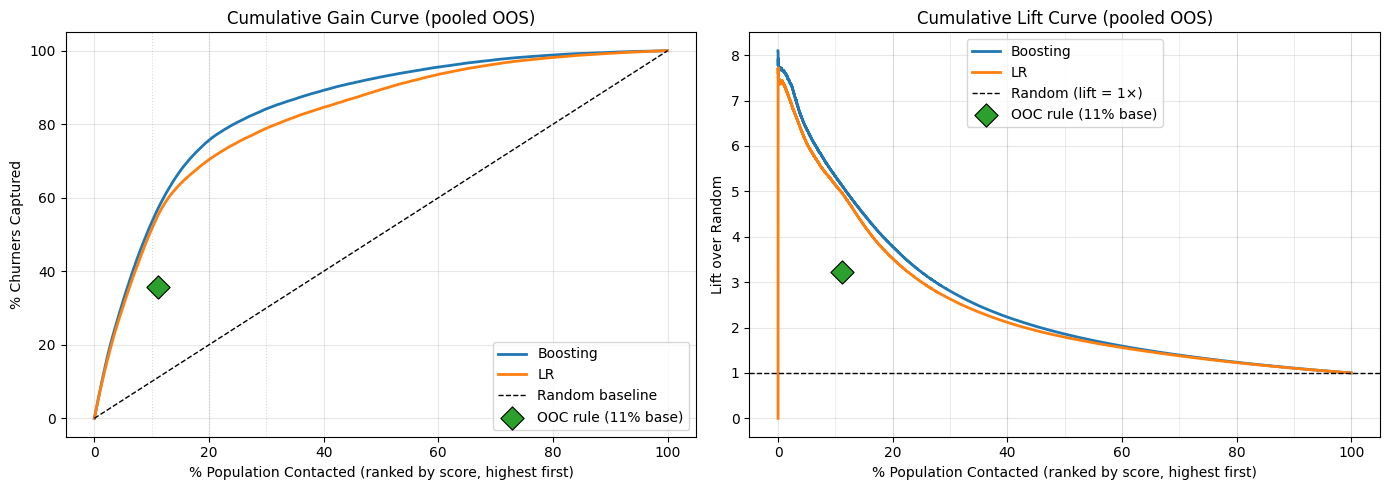

In [204]:
# Lift chart with rule point overlaid
plot_lift_curves(
    all_y, boost_all, lr_all,
    rule_points=[(_rule_pct_pop, _rule_pct_churn, f'OOC rule ({_rule_pct_pop:.0%} base)')],
    save_path='lift_curves.png',
)

The diamond is what the SQL rule gets you; the model curves show what you get at every budget level. In my opinion the model earns its place on three things the rule can't do: (1) it **ranks within** the approaching OOC group, so we call the highest risk customers first instead of treating them all the same; (2) it catches in contract churners the rule never sees; and (3) it gives us calibrated probabilities which we can actually use for expected value maths and deciding who goes to phone vs email. And if the model and rule had landed in the same place, we would still take that as a result as it would tell us the dominant signal is real, and the model is adding precision on top.

The lift curve directly answers the question the retention team actually asks: *"If we can only contact X% of our customers, how many leavers do we reach?"* Top 10% of the ranked list → ~53% of all churners captured. That is a **5.3× improvement over calling at random**

## 7. Probability Calibration

Class weighting improves minority-class sensitivity but causes the raw scores to become poorly calibrated as probabilities. Isotonic regression monotonically maps raw scores to calibrated probabilities, ranking (AUC) is unchanged, only the scale is fixed.

The diagnostic split is **temporal**: the calibrator is fit on the first 50% of OOS predictions (earlier CV windows) and evaluated on the last 50% (later windows), matching the time-ordered structure of the walk forward CV. The final production calibrator is then refit on all pooled OOS data.


Brier  raw    : 0.1122
Brier  calib  : 0.0673   (lower = better)
Mean raw score: 0.303  vs true churn rate 0.124
Mean calibrated:0.117  vs true churn rate 0.124
AUC  raw=0.8930  calib=0.8929  (identical — monotonic map)


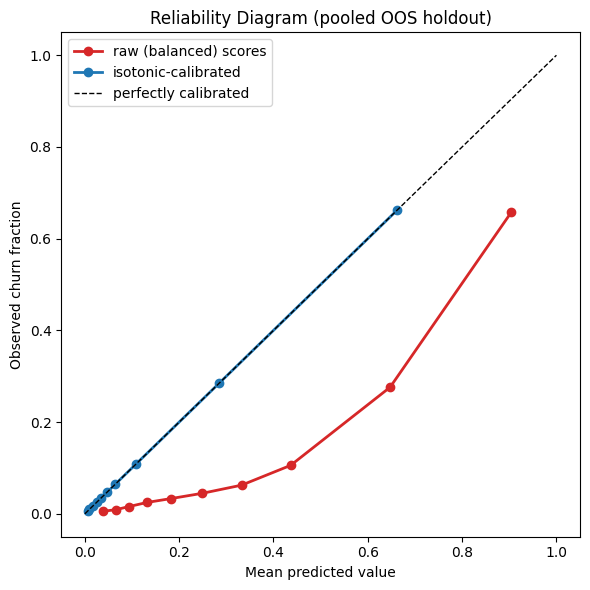

In [205]:
iso_cal, diag = calibrate_isotonic(all_y, boost_all)

print(f'Brier  raw    : {diag["brier_raw"]:.4f}')
print(f'Brier  calib  : {diag["brier_calibrated"]:.4f}   (lower = better)')
print(f'Mean raw score: {diag["mean_raw"]:.3f}  vs true churn rate {diag["true_rate"]:.3f}')
print(f'Mean calibrated:{diag["mean_calibrated"]:.3f}  vs true churn rate {diag["true_rate"]:.3f}')
print(f'AUC  raw={diag["auc_raw"]:.4f}  calib={diag["auc_calibrated"]:.4f}  (identical — monotonic map)')

plot_calibration(all_y, boost_all, iso_cal)

We use the raw `churn_score` for ranking and prioritising the call list (ranking is preserved under any monotone map, so the raw score is equally valid for ordering). We use `calibrated_prob` whenever we quote a number, expected value calculations, dashboard figures, stakeholder communications. We Do not swap them: a raw score of 0.7 does not mean a 70% chance of leaving.

## 8. Class Imbalance — Treatment & Threshold Optimisation

**Imbalance ratio:** ~7:1 (stay:churn). Treatment per model:
- HistGBM and LR use `class_weight='balanced'` — minority up-weighted ×7 in loss
- XGBoost uses `scale_pos_weight=7` — equivalent mechanism

**Why not SMOTE?** With 3M+ rows there is no sample scarcity. Tabular interpolation adds noise on mixed-type features, `class_weight` achieves the same gradient effect without touching the data, and SMOTE creates leakage risk in a pipeline context.

**Threshold:** The default t=0.5 is suboptimal for this business objective because the cost of missed churners greatly exceeds the cost of unnecessary outreach (see score distribution below). Two operating points are reported: the F1-optimal threshold (maximises balanced precision/recall) and the min-cost threshold (minimises expected business cost given the £6/£300 FP/FN cost matrix).


Stay  (0):   605,334  (87.65%)
Churn (1):    85,285  (12.35%)
Imbalance ratio: 7.1:1


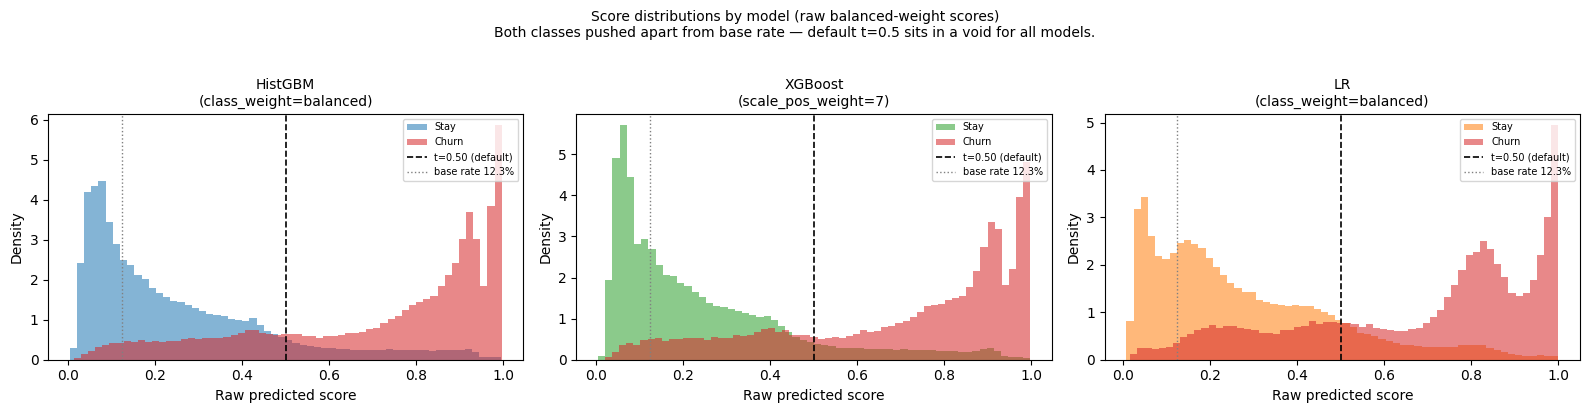

In [206]:
from collections import Counter
counts = Counter(all_y)
ratio  = counts[0] / counts[1]
print(f'Stay  (0): {counts[0]:>9,}  ({counts[0]/len(all_y):.2%})')
print(f'Churn (1): {counts[1]:>9,}  ({counts[1]/len(all_y):.2%})')
print(f'Imbalance ratio: {ratio:.1f}:1')

plot_score_distributions(all_y, boost_all, xgb_all, lr_all)

In [207]:
thresholds = np.arange(0.02, 0.85, 0.005)
thresh_df = compute_threshold_metrics(all_y, boost_all, thresholds, COST_FP, COST_FN)

t_f1   = thresh_df.loc[thresh_df['f1'].idxmax(),            'threshold']
t_cost = thresh_df.loc[thresh_df['business_cost'].idxmin(), 'threshold']

print('Optimal thresholds (Boosting, pooled OOS):')
print(f'  Max F1   (balanced)   : t = {t_f1:.3f}')
print(f'  Min cost (FP=£{COST_FP}, FN=£{COST_FN}): t = {t_cost:.3f}')

print(f'\n{"Threshold":>10} {"Precision":>10} {"Recall":>8} {"F1":>7} {"Flagged%":>9} {"Cost £M":>9}')
print('-' * 65)
for t_mark, label in [(t_f1, 'best F1'), (t_cost, 'min cost'), (0.5, 'default')]:
    row = thresh_df.iloc[(thresh_df['threshold'] - t_mark).abs().argsort().iloc[0]]
    print(f'{row["threshold"]:>10.3f} {row["precision"]:>10.3f} {row["recall"]:>8.3f} '
          f'{row["f1"]:>7.3f} {row["flagged_pct"]:>9.1%} '
          f'{row["business_cost"]/1e6:>9.2f}  <- {label}')

Optimal thresholds (Boosting, pooled OOS):
  Max F1   (balanced)   : t = 0.685
  Min cost (FP=£20, FN=£300): t = 0.345

 Threshold  Precision   Recall      F1  Flagged%   Cost £M
-----------------------------------------------------------------
     0.685      0.578    0.646   0.610     13.8%      9.86  <- best F1
     0.345      0.317    0.862   0.463     33.6%      6.70  <- min cost
     0.500      0.462    0.761   0.575     20.4%      7.63  <- default


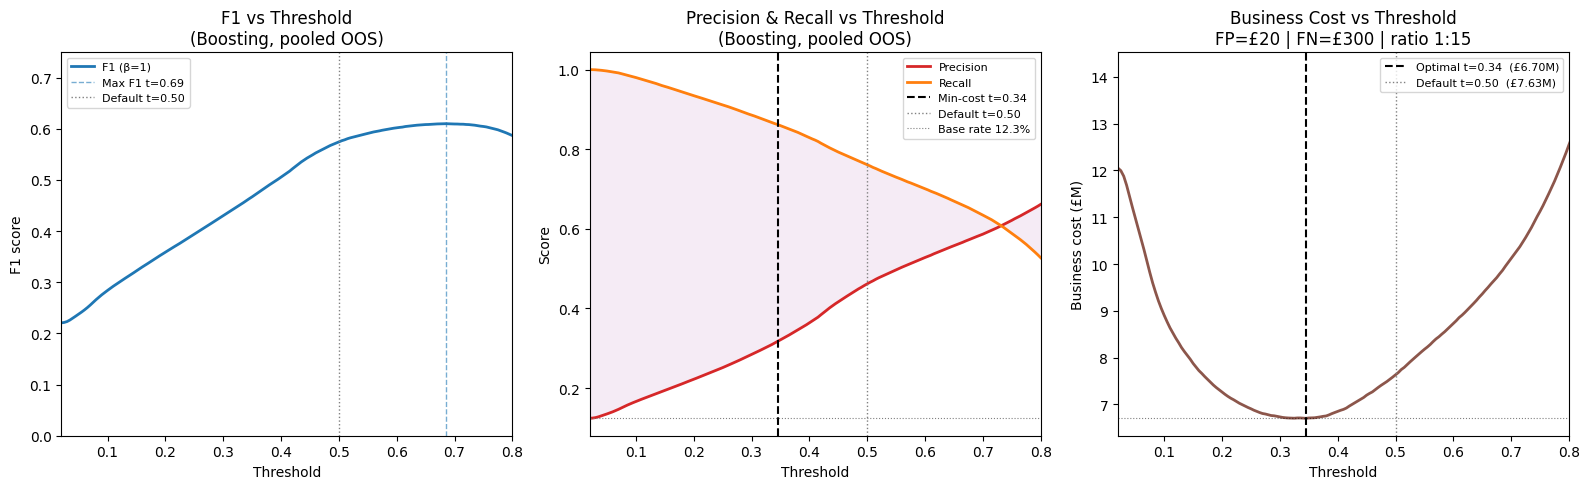

Cost at default t=0.50  : £7.63M
Cost at optimal t=0.34: £6.70M
Saving from threshold optimisation: £0.93M  (12.2% reduction)


In [208]:
plot_threshold_analysis(thresh_df, t_f1, t_cost, all_y, COST_FP, COST_FN)

cost_min_val = thresh_df['business_cost'].min()
cost_at_05   = thresh_df.iloc[(thresh_df['threshold'] - 0.5).abs().argsort().iloc[0]]['business_cost']
saving = cost_at_05 - cost_min_val
print(f'Cost at default t=0.50  : £{cost_at_05/1e6:.2f}M')
print(f'Cost at optimal t={t_cost:.2f}: £{cost_min_val/1e6:.2f}M')
print(f'Saving from threshold optimisation: £{saving/1e6:.2f}M  ({saving/cost_at_05:.1%} reduction)')

### Cost matrix

| | Predicted Stay | Predicted Churn |
|---|---|---|
| **Actual Stay** | £0 (TN) | £6 (FP — wasted call) |
| **Actual Churn** | £300 (FN — lost LTV) | £0 (TP) |

**Where these numbers come from:**

- **£6 FP** — cost of one outbound retention call. ContactBabel's 2023–24 UK Customer Experience Decision-Makers' Guide puts the industry average at £4–£6.26 per call; outbound campaigns are priced at £20–30/hr, making a ~15-minute call ~£5–7.50. £6 sits in the middle of that range. Source: [Call Centre Helper](https://www.callcentrehelper.com/poll-what-is-your-average-cost-per-call-68854.htm), [Callin.io UK pricing](https://callin.io/outsourced-call-centre-pricing-uk/).
- **£300 FN** — value of a successfully retained customer. TalkTalk's reported ARPU is **£25.46/month** (2024 accounts, via [ISPreview](https://www.ispreview.co.uk/index.php/2025/08/broadband-isp-talktalk-publish-uk-accounts-to-reveal-surge-in-losses.html)). If a retention call extends tenure by ~12 months: 12 × £25.46 = **£305 ≈ £300**.

Business cost asymmetry (FN:FP) = 50:1. **F1** is used as the balanced classification metric for model
selection and threshold tuning. The min-cost threshold additionally reflects the
business cost asymmetry and is the recommended deployment operating point.

The absolute £M figures scale linearly with these inputs. In production both should be replaced
with actuals from the call centre cost model and a CRM derived LTV estimate.

The cost model assumes every contacted churner is successfully retained. In practice a typical campaign save rate is 15–30%, which would raise the cost-optimal threshold (fewer contacts needed to break even). Replace with campaign actuals before go-live — but the directional recommendation (contact broadly, route cheaply) holds across any plausible save rate.